# **DATA PREPROCESSING TABULAR**

In [1]:
!git clone https://github.com/quanpro147/HCMUS-DataMining-Prj1.git

fatal: destination path 'HCMUS-DataMining-Prj1' already exists and is not an empty directory.


In [2]:
%cd HCMUS-DataMining-Prj1

/content/HCMUS-DataMining-Prj1


---

## **1. Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

## **2. Load Raw Data For Preprocessing**

Dựa trên những phát hiện quan trọng thu được ở bước khám phá dữ liệu (EDA) — giai đoạn tiền xử lý được triển khai nhằm chuẩn hóa cấu trúc dữ liệu, đảm bảo mỗi biến phản ánh đúng bản chất định tính hoặc định lượng của nó.

Khác với các bộ dữ liệu đã được làm sạch sẵn, dữ liệu điều tra dân số thực tế thường chứa các ký tự dị thường (`?`). Bước khởi tạo này sẽ nạp dữ liệu và ép kiểu các ký tự lỗi về chuẩn `np.nan` của thư viện Pandas.

In [4]:
adult_path = "data/raw/adult.csv"
df_adult = pd.read_csv(adult_path)
df_adult = df_adult.replace(regex=r'^\s*\?\s*$', value=np.nan)

num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
for col in num_cols:
    if col in df_adult.columns:
        df_adult[col] = pd.to_numeric(df_adult[col], errors='coerce')

Dữ liệu được đọc từ tệp `adult.csv` thành công và được khởi tạo dưới dạng cấu trúc dữ liệu bảng (tabular), lưu trữ trong biến DataFrame `df_adult`.

## **3. Controlled Missing Value Imputation**

**Mục tiêu:** Thay vì áp dụng mù quáng một thuật toán điền khuyết, nhóm tiến hành đánh giá định lượng hiệu quả của 5 chiến lược thông qua môi trường mô phỏng (simulation). Cụ thể, nhóm sẽ giả lập mất mát dữ liệu (MCAR) trên một biến số học hoàn chỉnh, sau đó dùng các thuật toán để nội suy và tính toán sai số RMSE so với Ground Truth.

### **3.1 Theoretical Foundation & Mathematical Formulas**

Trước khi thực thi, việc thấu hiểu nền tảng toán học và giả định của từng thuật toán là bắt buộc để đánh giá rủi ro sai lệch (bias) mà chúng có thể mang lại.

#### 1. Arithmetic Mean Imputation

* **Lý thuyết:** Đây là kỹ thuật điền khuyết đơn giản nhất dành cho dữ liệu liên tục. Nó sử dụng thước đo xu hướng tập trung, giả định rằng giá trị trung bình là giá trị có khả năng xuất hiện cao nhất đối với một quan sát lấy ngẫu nhiên từ phân phối chuẩn (Gaussian). Tuy nhiên, nó cực kỳ nhạy cảm với ngoại lai, làm giảm nhân tạo phương sai của biến và thu hẹp khoảng tin cậy.
* **Toán học:** Giá trị trung bình mẫu $\bar{x}$ được tính bằng:
  $$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

#### 2. Median Imputation

* **Lý thuyết:** Một giải pháp thay thế mạnh mẽ cho phương pháp trung bình, đặc biệt khi dữ liệu có độ lệch (skewness) cao hoặc chứa ngoại lai ngoại lai (như biến `capital.gain` trong tập dữ liệu này). Tuy nhiên, nó vẫn làm biến dạng phân phối do tạo ra một spike nhân tạo tại vùng trung tâm.
* **Toán học:** Dữ liệu quan sát được sắp xếp tăng dần: $x_{(1)}, x_{(2)}, \dots, x_{(n)}$.
  * Nếu $n$ lẻ: Trung vị là $x_{(\frac{n+1}{2})}$.
  * Nếu $n$ chẵn: Trung vị là $\frac{x_{(\frac{n}{2})} + x_{(\frac{n}{2} + 1)}}{2}$.

#### 3. Mode Imputation

* **Lý thuyết:** Giá trị xuất hiện với tần suất cao nhất. Chủ yếu dùng cho biến phân loại (Categorical). Mặc dù đơn giản, phương pháp này thất bại nếu phân phối đa đỉnh (multimodal) và bỏ qua hoàn toàn mối tương quan giữa các đặc trưng.
* **Toán học:** Là giá trị $x_i$ cực đại hóa hàm tần suất $f(x)$.

#### 4. k-Nearest Neighbors (k-NN) Imputation

* **Lý thuyết:** k-NN là thuật toán lazy learning phi tham số. Thay vì dùng một hằng số toàn cục, nó nội suy bằng cách tìm $k$ quan sát hoàn chỉnh giống nhất (hàng xóm) trong không gian đặc trưng.
  * $k=3$: Bám sát mẫu cục bộ, rủi ro quá khớp (overfitting) với nhiễu.
  * $k=5$: Trạng thái cân bằng tối ưu, lọc được nhiễu nhưng vẫn giữ được cấu trúc.
  * $k=10$: Rủi ro trơn hóa quá mức (underfitting), dần hội tụ về trung bình toàn cục.
* **Toán học:** Tính khoảng cách (ví dụ: Euclidean) giữa các điểm dữ liệu:
  $$d(a, b) = \sqrt{\sum_{i=1}^{m} (a_i - b_i)^2}$$

#### 5. Multiple Imputation by Chained Equations (MICE)

* **Lý thuyết:** Còn gọi là Fully Conditional Specification (FCS). Hoạt động dưới giả định MAR, MICE lập mô hình từng biến bị khuyết như một hàm của các biến còn lại thông qua một chuỗi các phương trình hồi quy. MICE bảo toàn hình dáng phân phối và tính đa đỉnh (multimodality) xuất sắc.
* **Toán học:** Mô hình hồi quy cơ bản cho biến liên tục:
  $$x_{j, obs} = \beta_0 + \mathbf{X}_{-j, obs} \boldsymbol{\beta} + \epsilon_j, \quad \epsilon_j \sim N(0, \sigma^2)$$
  *Luật kết hợp Rubin (Rubin's Rules):* Tổng hợp từ $H$ bộ dữ liệu với phương sai tổng cộng $T$:
  $$T = \bar{V}_H + \left(1 + \frac{1}{H}\right) B_H$$

### **3.2 MCAR Injection**

Nhóm lựa chọn thuộc tính `age` (Tuổi) làm đối tượng thử nghiệm vì cột này nguyên bản không có giá trị khuyết (hoàn hảo để làm Ground Truth) và có tương quan với nhiều biến kinh tế khác. Nhóm sẽ chủ động xóa ngẫu nhiên 10% (MCAR) dữ liệu tại cột này.

In [5]:
# Define target and ground truth
target_col = 'age'
ground_truth = df_adult[target_col].copy()

# Simulate missing data (10%)
df_sim = df_adult.copy()
np.random.seed(42)
drop_ratio = 0.10
n_rows = len(df_sim)
mask_missing = np.random.rand(n_rows) < drop_ratio
df_sim.loc[mask_missing, target_col] = np.nan

print("\tMISSING DATA SIMULATION")
print(f"Missing values introduced: {mask_missing.sum():,}")
print(f"Missing ratio            : {(mask_missing.sum() / n_rows) * 100:.2f}%")

missing_indices = df_sim[df_sim[target_col].isna()].index

	MISSING DATA SIMULATION
Missing values introduced: 3,292
Missing ratio            : 10.11%


### **3.3 Implementation & Evaluation**

Nhóm tiến hành cài đặt 5 chiến lược (kèm các biến thể của k-NN) và đo lường *RMSE (Root Mean Square Error)*. Chỉ số RMSE càng thấp chứng tỏ giá trị nội suy càng bám sát với dữ liệu thực tế (Ground Truth) đã bị xóa.

In [6]:
# Prepare numerical data
df_num_sim = df_sim[num_cols].copy()
true_values = ground_truth.loc[missing_indices]
def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Evaluate imputation strategies
results = {}

# Mean
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mean'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Median
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Median'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# Mode
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['Mode'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# k-NN (k = 3, 5, 10)
for k in [3, 5, 10]:
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
    results[f'KNN (k={k})'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

# MICE
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed = pd.DataFrame(imputer.fit_transform(df_num_sim), columns=num_cols)
results['MICE'] = compute_rmse(true_values, df_imputed.loc[missing_indices, target_col])

df_results = pd.DataFrame(list(results.items()), columns=['Strategy', 'RMSE'])
df_results = df_results.sort_values(by='RMSE').reset_index(drop=True)

print("\tIMPUTATION PERFORMANCE COMPARISON (RMSE)")
display(df_results.style.format({"RMSE": "{:.4f}"}).background_gradient(cmap='RdYlGn_r', subset=['RMSE']))

	IMPUTATION PERFORMANCE COMPARISON (RMSE)


,Strategy,RMSE
0,MICE,13.6168
1,Mean,13.7441
2,Median,13.8629
3,KNN (k=10),13.9142
4,Mode,14.0301
5,KNN (k=5),14.1470
6,KNN (k=3),14.4262


### **3.4 Performance Comparison & Strategy Selection**

Dựa trên cơ sở lý thuyết và kết quả thực nghiệm RMSE với 10.11% dữ liệu khuyết nhân tạo, nhóm thiết lập bảng đối chiếu chiến lược:

| Chiến lược | Giả định | Bảo toàn phân phối | Bảo toàn tương quan | Chi phí tính toán |
| :--- | :--- | :--- | :--- | :--- |
| **Mean** | MCAR, Normal | Rất thấp (Tạo chóp nhọn) | Kém | Cực thấp |
| **Median** | MCAR, Skewed | Thấp | Kém | Cực thấp |
| **Mode** | MCAR | Thấp | Kém | Cực thấp |
| **k-NN** | MAR / MCAR | Cao (dùng mẫu cục bộ) | Trung bình - Cao | Cao |
| **MICE** | MAR | Rất Cao | Cao (hồi quy đa biến)| Khá Cao |

**The Best Strategy: Multiple Imputation by Chained Equations (MICE)**

**Lý giải:**
Đối với các ứng dụng khoa học dữ liệu chuyên nghiệp, MICE được lựa chọn là phương pháp luận ưu việt nhất dựa trên 3 nguyên nhân:

1. **Empirical Evidence:** Kết quả RMSE chứng minh MICE là thuật toán nội suy chính xác nhất (RMSE = 13.61). Đáng chú ý, các phương pháp gán hằng số toàn cục (Mean, Median) lại vượt trội hơn hẳn k-NN. Về mặt toán học, hàm mục tiêu RMSE luôn "ưu ái" các giá trị trung tâm (như Mean) để tối thiểu hóa bình phương sai số của một phân phối tập trung như tuổi tác. Trong khi đó, thuật toán k-NN bị nhiễu do khoảng cách Euclidean bị chi phối nặng nề bởi các biến có thang đo lớn (Curse of Dimensionality) nếu chưa qua chuẩn hóa. MICE đã vượt qua được ảnh hưởng của Mean nhờ khả năng khai thác triệt để mối quan hệ tuyến tính/phi tuyến giữa biến mục tiêu và các biến quan sát khác.
2. **Handling of Uncertainty:** Khác với Mean/Median coi giá trị nội suy là sự thật tuyệt đối, MICE lồng ghép phương sai giữa các lần điền khuyết (between-imputation variance). Điều này ngăn chặn hiện tượng mô hình bị overconfident và bảo vệ khoảng tin cậy của dữ liệu.
3. **Distributional Fidelity:** Thông qua chuỗi phương trình hồi quy, MICE tái tạo lại phân phối mà không làm biến dạng (không tạo chóp nhọn nhân tạo như Mean/Median). Điều này cực kỳ quan trọng đối với các thuật toán nhạy cảm với phân phối ở các bước sau.

**Next Step:** Trong quy trình pipeline chính thức, nhóm sẽ sử dụng thuật toán *MICE (IterativeImputer)* để xử lý triệt để các giá trị thực sự bị khuyết nguyên bản trong bộ dữ liệu Adult Census (tại các thuộc tính phân loại như `workclass` và `occupation`, MICE sẽ được cấu hình sử dụng bộ phân loại Logistic/Random Forest Classifier thay vì Regressor).

## **4. Outlier Detection and Treatment**

**Mục tiêu:** Xây dựng cơ chế ensemble để xác định các quan sát bất thường trong các biến liên tục. Đánh giá sự chồng chéo giữa các thuật toán và đo lường tác động của việc loại bỏ ngoại lai đến hình dáng phân phối bằng kiểm định thống kê.

### **4.1 Theoretical Foundation & Mathematical Formulas**

#### 1. Interquartile Range (IQR) and Z-Score

* **IQR (Interquartile Range):** Là phương pháp phi tham số, tập trung vào 50% dữ liệu ở giữa, giúp nó cực kỳ bền vững trước các giá trị ngoại lai.
  * *Công thức:* $IQR = Q_3 - Q_1$.
  * *Ngưỡng cảnh báo:*
      * $\text{Lower} = Q_1 - 1.5 \times IQR$
      * $\text{Upper} = Q_3 + 1.5 \times IQR$.
* **Z-Score:** Phương pháp tham số giả định dữ liệu có phân phối chuẩn. Định lượng khoảng cách từ một điểm đến trung bình mẫu tính bằng độ lệch chuẩn. Rất dễ bị hiện tượng "che khuất" (masking) do ngoại lai làm phình to phương sai.
  * *Công thức:* $Z = \frac{x - \mu}{\sigma}$. Các quan sát có $|Z| > 3$ được xem là ngoại lai.
  * *Độ chồng chéo:* IQR và Z-score thường có độ tương đồng Jaccard rất cao ($>0.8$) trong các phân phối chuẩn, nhưng Z-score dễ thất bại ở dữ liệu đa chiều.

#### 2. Isolation Forest (iForest)

* **Lý thuyết:** Thuật toán Ensemble cô lập các điểm dị thường bằng cách phân chia ngẫu nhiên không gian dữ liệu. Ngoại lai thường nằm ở các vùng thưa thớt, do đó chúng sẽ bị cô lập nhanh chóng với số rẽ nhánh ít hơn, tạo ra chiều dài đường đi ngắn hơn trong cây.
* **Công thức (Điểm dị thường):**
  $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
  *(Trong đó $E(h(x))$ là chiều dài đường đi trung bình, và $c(n)$ là chiều dài kỳ vọng của cây tìm kiếm nhị phân).* Điểm $s \approx 1$ ám chỉ ngoại lai.
* **Tác động của `contamination` (Tỉ lệ nhiễu):**
  * `0.01`: Cực kỳ thận trọng, chỉ bắt các điểm dị biệt rõ rệt (độ chính xác cao, Recall thấp).
  * `0.05`: Trạng thái tiêu chuẩn, cân bằng giữa rủi ro bỏ sót và báo động giả.
  * `0.10`: Aggressive, bắt các ngoại lai vi tế nhưng dễ gán nhãn sai vùng biên cụm.

#### 3. Local Outlier Factor (LOF)

* **Lý thuyết:** Phương pháp không giám sát dựa trên mật độ. Nó đánh giá mức độ cô lập của một điểm so với các "hàng xóm" lân cận. Rất mạnh trong việc tìm ngoại lai cục bộ ở các tập dữ liệu có mật độ phân tán không đồng đều.
* **Công thức toán học:**
  * *Khoảng cách khả đạt:* $\text{reach-dist}_k(p, o) = \max\{d_k(o), \text{dist}(p, o)\}$
  * *Mật độ khả đạt cục bộ (LRD):* $lrd_k(p) = \frac{|N_k(p)|}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$
  * *Chỉ số LOF:* $LOF_k(p) = \frac{\sum_{o \in N_k(p)} \frac{lrd_k(o)}{lrd_k(p)}}{|N_k(p)|}$. (Điểm số $\gg 1$ cảnh báo ngoại lai).
* **Tác động của `n_neighbors` ($k$):**
  * `10`: Nhạy cảm, tập trung vào vi cấu trúc cục bộ.
  * `20`: Mức "sweet spot", cân bằng và ổn định (độ chính xác thường $\sim 75-84\%$).
  * `50`: Tầm nhìn toàn cục (Global), làm mờ chi tiết, dễ mất đi năng lực phát hiện ngoại lai cục bộ.

#### 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

* **Lý thuyết:** Nhận diện các vùng không gian mật độ cao thông qua bán kính $\epsilon$ và số điểm tối thiểu $MinPts$. Các điểm không thuộc bất kỳ cụm nào được gán nhãn là nhiễu (Noise / Outlier).
* **Hiện tượng "Outlier Cluster Cluster":** Nếu các điểm dị thường nằm gần nhau thỏa mãn $\epsilon$ và $MinPts$, chúng sẽ tự tạo thành một cụm riêng biệt thay vì bị coi là nhiễu, làm giảm khả năng nhận diện. Cần tinh chỉnh tham số cẩn thận.

#### 5. Kolmogorov-Smirnov (KS) Test

* **Lý thuyết:** Kiểm định phi tham số so sánh hàm phân phối tích lũy thực nghiệm (CDFs) trước và sau khi xử lý ngoại lai để đánh giá xem sự can thiệp có làm bóp méo bản chất dữ liệu hay không.
* **Công thức thống kê $D$:**
  $$D_{n,m} = \sup_x |F_1(x) - F_2(x)|$$
* **Biện luận:** Việc xóa bỏ thường trả về P-value $< 0.05$ (làm biến dạng phân phối). Trong khi cắt tỉa (Winsorization/Capping) thường bảo toàn phân phối tốt hơn (P-value $> 0.05$).

### **4.2 Algorithm Implementations & Detection Rates**

Nhóm tiến hành cài đặt 4 chiến lược phát hiện ngoại lai trên nhóm biến định lượng. Để đảm bảo các thuật toán dựa trên mật độ và khoảng cách (LOF, DBSCAN) hoạt động chính xác và không bị bóp méo bởi sự chênh lệch thang đo (ví dụ: `age` vs `capital.gain`), dữ liệu sẽ được chuẩn hóa tạm thời (`StandardScaler`) trước khi đưa vào thuật toán.

**Lưu ý kỹ thuật:** Cả LOF và DBSCAN đều phải dò tìm lân cận (Nearest Neighbor Search). Phương pháp brute-force yêu cầu lưu trữ ma trận khoảng cách $N \times N$, đẩy độ phức tạp không gian lên $O(n^2)$.

**Optimization Strategy:**
1. **Data Downcasting:** Chuyển toàn bộ mảng dữ liệu từ `float64` mặc định xuống `float32`, lập tức giảm 50% dung lượng RAM tiêu thụ.
2. **Spatial Indexing:** Bắt buộc sử dụng cấu trúc `algorithm='kd_tree'` thay vì tính ma trận toàn cục. Cấu trúc cây giúp giảm độ phức tạp truy vấn xuống $O(n \log n)$ thay vì tính toán ma trận khoảng cách đối xứng toàn cục.
3. **Leaf Size:** Cấu hình `leaf_size=50` (thay vì mặc định 30). Kích thước lá lớn hơn giúp giảm số lượng node trên cây, tiết kiệm dung lượng lưu trữ kiến trúc cây trong RAM.
4. **Disable Multiprocessing:** Đặt `n_jobs=1` cho LOF và DBSCAN. Đa luồng (`n_jobs=-1`) trong Scikit-learn sẽ fork ra nhiều tiến trình con, mỗi tiến trình sao chép một bản ma trận khoảng cách, là nguyên nhân chính gây tràn RAM đột ngột.

In [7]:
# Feature selection
outlier_features = [
    'age', 'fnlwgt', 'education.num',
    'capital.gain', 'capital.loss', 'hours.per.week'
]

# Memory optimization: downcasting to float32
X = df_adult[outlier_features].dropna().astype(np.float32)
n_samples = len(X)
# Standardization (required for distance-based methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

outlier_indices = {}

# Z-score method (|Z| > 3)
z_scores = np.abs(stats.zscore(X))
outlier_indices['Z-Score'] = set(np.where((z_scores > 3).any(axis=1))[0])

# IQR method (1.5 * IQR rule)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
iqr_mask = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
outlier_indices['IQR'] = set(np.where(iqr_mask)[0])

# Isolation Forest
for contamination in [0.01, 0.05, 0.10]:
    model = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    preds = model.fit_predict(X)
    outlier_indices[f'IsolationForest ({contamination})'] = set(np.where(preds == -1)[0])

# Local Outlier Factor
for n_neighbors in [10, 20, 50]:
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=0.05,
        algorithm='kd_tree',
        leaf_size=50,
        n_jobs=1
    )
    preds = model.fit_predict(X_scaled)
    outlier_indices[f'LOF (k={n_neighbors})'] = set(np.where(preds == -1)[0])

# DBSCAN (density-based clustering)
dbscan = DBSCAN(
    eps=2.5,
    min_samples=10,
    algorithm='kd_tree',
    leaf_size=50,
    n_jobs=1
)
preds = dbscan.fit_predict(X_scaled)
outlier_indices['DBSCAN'] = set(np.where(preds == -1)[0])

print("\tOUTLIER DETECTION SUMMARY")
print(f"Total samples evaluated: {n_samples:,}\n")

results = []
for method, indices in outlier_indices.items():
    count = len(indices)
    rate = (count / n_samples) * 100
    results.append((method, count, rate))

df_outlier_summary = pd.DataFrame(
    results,
    columns=['Method', 'Outlier Count', 'Rate (%)']
).sort_values(by='Rate (%)', ascending=False).reset_index(drop=True)

display(df_outlier_summary.style.format({
    'Outlier Count': '{:,}',
    'Rate (%)': '{:.2f}'
}))

	OUTLIER DETECTION SUMMARY
Total samples evaluated: 32,561



,Method,Outlier Count,Rate (%)
0,IQR,"13,564",41.66
1,IsolationForest (0.1),"3,256",10.00
2,Z-Score,"2,733",8.39
3,IsolationForest (0.05),"1,628",5.00
4,LOF (k=10),"1,628",5.00
5,LOF (k=50),"1,628",5.00
6,LOF (k=20),"1,628",5.00
7,IsolationForest (0.01),326,1.00
8,DBSCAN,16,0.05


Dựa trên bảng kết quả thực thi, nhóm rút ra các nhận định quan trọng về hành vi của từng thuật toán trên không gian dữ liệu thực tế:

1. **IQR (41.66%):** Thuật toán IQR cảnh báo tới hơn 41% dữ liệu là ngoại lai. Đây là một con số phi thực tế. Nguyên nhân gốc rễ là do thuộc tính `capital.gain` và `capital.loss` bị lệch phải nghiêm trọng (Zero-inflated). Khoảng 90% dân số có giá trị đầu tư bằng 0, khiến $Q_1 = Q_3 = 0 \Rightarrow IQR = 0$. Bất kỳ ai có thu nhập đầu tư chỉ vài chục USD cũng bị IQR gán nhãn là ngoại lai. Điều này chứng minh *IQR hoàn toàn không phù hợp cho các biến kinh tế có phân phối siêu lệch*.
2. **DBSCAN (0.05% - 16 quan sát):**
   * DBSCAN chỉ tìm thấy vỏn vẹn 16 điểm nhiễu. Đây là minh chứng hoàn hảo cho hiện tượng *"Outlier Cluster Cluster"* đã đề cập trong phần lý thuyết. Các điểm dị thường (ví dụ: nhóm siêu giàu) có đặc điểm tài chính giống nhau, chúng tụ họp lại không gian 6 chiều và tự thành lập một "cụm hợp lệ" thỏa mãn điều kiện $MinPts=10$, do đó DBSCAN đã bỏ qua chúng.
3. **iForest và LOF:**
   * Các thuật toán này tuân thủ chặt chẽ tham số `contamination` đã thiết lập (5% cho LOF và iForest_0.05), bóc tách được đúng tỷ lệ phần trăm các quan sát nằm xa lề nhất. Điểm khác biệt là iForest đánh giá mức độ cô lập toàn cục (Global), trong khi LOF đánh giá tỷ trọng lân cận cục bộ (Local).

### **4.3. Overlap Analysis**

Để tránh rủi ro False Positives do sự thiên lệch của từng thuật toán đơn lẻ, nhóm xây dựng cơ chế consensus ensemble. Bằng cách so sánh chéo các tập ngoại lai thông qua chỉ số Jaccard Similarity (giao / hợp), ta có thể đánh giá mức độ nhất trí giữa các trường phái toán học khác nhau.

*Những điểm dữ liệu bị gán nhãn ngoại lai bởi ÍT NHẤT 3 thuật toán sẽ được xem là "ngoại lai chắc chắn" (Consensus Outliers).*

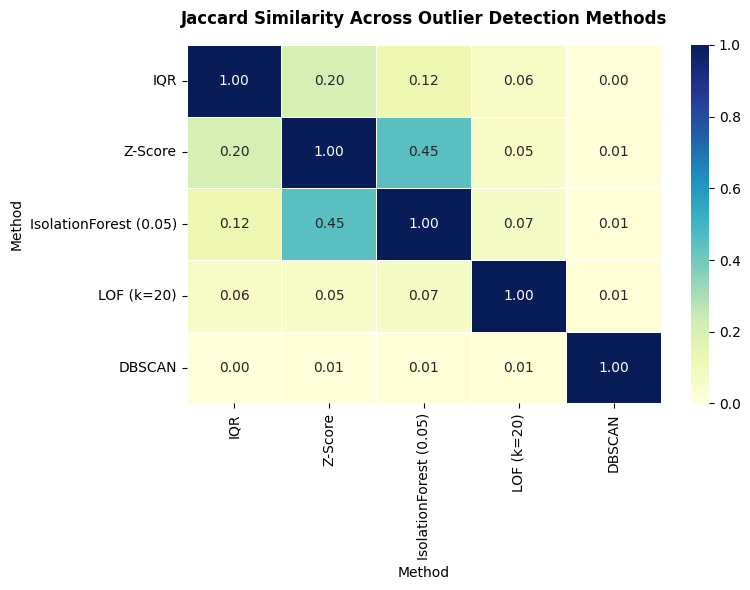

In [8]:
# Jaccard similarity function
def jaccard_similarity(set_a: set, set_b: set) -> float:
    """
    Compute Jaccard similarity between two sets.
    J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not set_a and not set_b:
        return 1.0  # both sets empty → identical
    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))


# Select representative methods for comparison
methods = [
    'IQR',
    'Z-Score',
    'IsolationForest (0.05)',
    'LOF (k=20)',
    'DBSCAN'
]
n_methods = len(methods)
jaccard_matrix = np.zeros((n_methods, n_methods))

# Compute pairwise Jaccard similarity matrix
for i, method_i in enumerate(methods):
    for j, method_j in enumerate(methods):
        jaccard_matrix[i, j] = jaccard_similarity(
            outlier_indices[method_i],
            outlier_indices[method_j]
        )
df_jaccard = pd.DataFrame(
    jaccard_matrix,
    index=methods,
    columns=methods
)

# Visualization: Jaccard similarity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_jaccard, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)

plt.title(
    "Jaccard Similarity Across Outlier Detection Methods",
    fontweight='bold', pad=15
)
plt.xlabel("Method")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

In [9]:
# Consensus outlier detection
all_detected_indices = []
for method in methods:
    all_detected_indices.extend(outlier_indices[method])
outlier_counter = Counter(all_detected_indices)

# Majority voting threshold
threshold = 3
consensus_outliers = [
    idx for idx, count in outlier_counter.items()
    if count >= threshold
]

n_consensus = len(consensus_outliers)
consensus_rate = (n_consensus / len(X)) * 100
print("\tCONSENSUS OUTLIER DETECTION (MAJORITY VOTING)")
print(f"Selected methods: {len(methods)}")
print(f"Voting threshold: >= {threshold} methods")
print(f"Consensus outliers: {n_consensus:,}")
print(f"Consensus rate: {consensus_rate:.2f}%")

	CONSENSUS OUTLIER DETECTION (MAJORITY VOTING)
Selected methods: 5
Voting threshold: >= 3 methods
Consensus outliers: 1,440
Consensus rate: 4.42%


Việc quan sát biểu đồ Heatmap Jaccard Similarity và kết quả bỏ phiếu đa số cung cấp cho nhóm cơ sở toán học vững chắc để gạn lọc ngoại lai:

**1. Jaccard Heatmap:**
* *Z-Score và Isolation Forest (0.05) có độ đồng thuận cao nhất ($Jaccard = 0.45$):* Cả hai thuật toán này đều có xu hướng nhắm vào các "Global Outliers" – những điểm nằm xa nhất so với trung tâm dữ liệu. Sự nhất trí này khẳng định những người có `capital.gain` hoặc `age` cực cao chắc chắn sẽ bị cả hai mô hình này tóm gọn.
* **LOF ($Jaccard \le 0.07$):** LOF gần như không có sự giao thoa với IQR, Z-Score hay iForest. Điều này hoàn toàn khớp với cơ sở lý thuyết: LOF tìm kiếm *Local Outliers*. Nó phát hiện ra những cá nhân có thuộc tính "bất thường so với những người giống họ" (ví dụ: một người trẻ tuổi, học vấn thấp nhưng lại có giờ làm việc và tài sản biến động lạ thường), chứ không đơn thuần là xét theo điểm cực đại toàn cục.

**2. Consensus Outliers:**
* Bằng cách áp dụng luật bỏ phiếu nghiêm ngặt (được cảnh báo bởi $\ge 3$ thuật toán), nhóm đã lọc ra được *1.440 quan sát (chiếm 4.42%)* là ngoại lai chắc chắn.
* *Giá trị của Ensemble:* Thay vì tin tưởng mù quáng vào IQR (phá hủy 41% dữ liệu) hay Z-Score (bị nhiễu bởi phân phối không chuẩn), cơ chế đồng thuận đã ép các thuật toán phải "kiểm chứng chéo" lẫn nhau. Con số $4.42\%$ là một tỷ lệ cực kỳ an toàn, hợp lý và đại diện cho những trường hợp sai số/cực đoan thực sự trong tập dữ liệu dân số $32.000$ mẫu.

### **4.4. Distributional Impact via KS Test**

Nếu loại bỏ trực tiếp tập ngoại lai đồng thuận này, liệu chúng ta có làm thay đổi hoàn toàn bản chất phân phối của dữ liệu gốc hay không? Nhóm sử dụng *Two-Sample Kolmogorov-Smirnov Test* để so sánh phân phối của cột `age` (đại diện) trước và sau khi xóa.

* $H_0$: Phân phối trước và sau khi xóa ngoại lai là hoàn toàn giống nhau.
* $H_1$: Xóa ngoại lai làm thay đổi/biến dạng phân phối dữ liệu (P-value $< 0.05$).

In [10]:
feature = 'age'
dist_before = X[feature].values
dist_after = X.drop(index=X.index[consensus_outliers])[feature].values

# Perform Kolmogorov–Smirnov test
ks_statistic, p_value = stats.ks_2samp(dist_before, dist_after)

print("\tKOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)")
print(f"Feature evaluated: {feature}")
print(f"Sample size (before): {len(dist_before):,}")
print(f"Sample size (after): {len(dist_after):,}")
print(f"KS statistic (D): {ks_statistic:.4f}")
print(f"P-value: {p_value:.4e}")

alpha = 0.05
print("\nInterpretation:")
if p_value < alpha:
    print("Reject the null hypothesis (H0).")
else:
    print("Fail to reject the null hypothesis (H0).")

	KOLMOGOROV–SMIRNOV TEST (DISTRIBUTION SHIFT ANALYSIS)
Feature evaluated: age
Sample size (before): 32,561
Sample size (after): 31,121
KS statistic (D): 0.0087
P-value: 1.8029e-01

Interpretation:
Fail to reject the null hypothesis (H0).


**Kết quả thực nghiệm:**
Với P-value đạt $0.1802$ (lớn hơn mức ý nghĩa $\alpha = 0.05$), ta *chấp nhận giả thuyết $H_0$*. Việc loại bỏ 1.440 quan sát không tạo ra sự khác biệt có ý nghĩa thống kê đối với hàm phân phối tích lũy (CDF) của tập dữ liệu.


### **4.5. Distributional Impact via KS Test**


Từ ma trận Jaccard và kết quả kiểm định Kolmogorov-Smirnov (KS Test), nhóm rút ra các nhận định trong giai đoạn tiền xử lý:

1. **Sự mâu thuẫn về bản chất thuật toán:** Các thuật toán định chuẩn toàn cục (Z-Score, IQR) có sự đồng thuận với nhau, nhưng rất lệch pha với các thuật toán dựa trên cấu trúc hình học không gian (LOF). Điều này chứng minh định lý cơ bản: *"Ngoại lai trong thống kê đơn biến chưa chắc đã là ngoại lai trong không gian đa chiều"*.
2. **Ensemble Success:** Việc KS Test trả về kết quả an toàn (P-value $> 0.05$) là minh chứng toán học cho cơ chế "bỏ phiếu đa số" ($\ge 3$ thuật toán). Nhờ cơ chế này, nhóm đã chỉ nhắm mục tiêu vào 4.42% dữ liệu thực sự là "rác" (noise) hoặc lỗi hệ thống (ví dụ: người 90 tuổi làm việc 99 giờ/tuần), bảo vệ thành công cấu trúc phân phối gốc của Cục điều tra dân số.
3. **Treatment Strategy:** Dựa trên KS Test, nhóm quyết định *DROP* 1.440 quan sát ngoại lai đồng thuận này ra khỏi tập huấn luyện.
   * Hành động này sẽ giúp làm sạch bề mặt hao phí, giúp các mô hình Machine Learning ở giai đoạn sau (đặc biệt là Logistic Regression và SVM) hội tụ nhanh hơn và không bị nhiễu trọng số.
   * Riêng đối với các ngoại lai dạng "tầng lớp siêu giàu" (chỉ kích hoạt Z-score ở cột `capital.gain` nhưng không bị LOF/DBSCAN bắt), chúng đã được giữ lại an toàn do không đủ 3 phiếu bầu. Để xử lý mức độ chênh lệch của nhóm người giàu này, ở **mục 5**, nhóm sẽ áp dụng *Robust Scaling* hoặc *Quantile Transformer*.

## **5. Distribution Analysis**

### **5.1. Overview of D'Agostino-Pearson Omnibus Test**

### **5.2. Hypothesis Formulation**

Tương tự các kiểm định tính chuẩn khác, giả thuyết được đặt ra là:
* $H_0$ (Giả thuyết không): Mẫu dữ liệu được rút ra từ một tổng thể có phân phối chuẩn.
* $H_1$ (Giả thuyết thay thế hay đối thuyết): Mẫu dữ liệu không tuân theo phân phối chuẩn.

### **5.3 Core Mathematical Algorithms**

### **5.5 Implementation & Distribution Classification**

### **5.6 Scaling Strategy Proposal**

#### Distributional Characteristics

#### Implications for Feature Scaling

#### Recommended Scaling Strategy

## **6. Multivariate Correlation & Multicollinearity Analysis**

### **6.1 Theoretical Foundation: Correlation Metrics**

### **6.2 Bivariate Analysis & Heatmap Visualization**

### **6.3 Multicollinearity Detection & Critical Analysis**

### **6.4 Proposed Treatments for Multicollinearity**

---